## Dataset Structure

The division of data within the Crack Segmentation Dataset is outlined as follows:

- **Training set**: Consists of 3717 images with corresponding annotations.

- **Testing set**: Comprises 112 images along with their respective annotations.

- **Validation set**: Includes 200 images with their corresponding annotations.

In [18]:
import ultralytics
ultralytics.checks()

Ultralytics 8.4.47  Python-3.12.13 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
Setup complete  (32 CPUs, 31.7 GB RAM, 706.3/1661.9 GB disk)


In [24]:
from ultralytics import YOLO

# Load a model
model = YOLO(
    "yolo26m-seg.pt"
)

In [3]:
# Train the model
results = model.train(
    data=r"D:\Develop\dataset\crack-multi-seg\data.yaml",
    epochs=3,
    imgsz=640,
    batch=64,
    workers=0,
)

New https://pypi.org/project/ultralytics/8.4.54 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.47  Python-3.12.13 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\Develop\dataset\crack-multi-seg\data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=3, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n-seg.pt, momentum=0

KeyboardInterrupt: 


image 1/1 D:\HP\Downloads\11860.jpg: 480x640 4 Breakages, 1 Reinforcement, 64.3ms
Speed: 3.0ms preprocess, 64.3ms inference, 1.7ms postprocess per image at shape (1, 3, 480, 640)


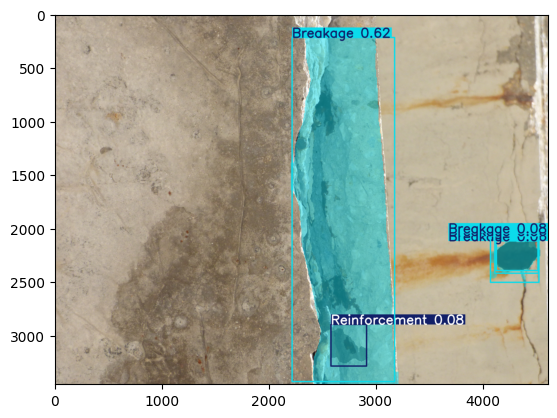

In [84]:
from ultralytics import YOLO
import matplotlib.pyplot as plt

# Load a model
modelp = YOLO("runs/segment/train/weights/best.pt")  # load a fine-tuned model

# Inference using the model (img/video/stream)
prediction_results = modelp.predict(
    r"D:\HP\Downloads\11860.jpg",
    save=False,
    conf=0.05,
)

plt.imshow(prediction_results[0].plot()[..., ::-1])  # 转换 BGR 到 RGB
plt.show()

In [85]:
import numpy as np
import cv2


def box_iou(box_a, box_b):
    x1 = max(box_a[0], box_b[0])
    y1 = max(box_a[1], box_b[1])
    x2 = min(box_a[2], box_b[2])
    y2 = min(box_a[3], box_b[3])

    inter_w = max(0.0, x2 - x1)
    inter_h = max(0.0, y2 - y1)
    inter_area = inter_w * inter_h

    area_a = max(0.0, box_a[2] - box_a[0]) * max(0.0, box_a[3] - box_a[1])
    area_b = max(0.0, box_b[2] - box_b[0]) * max(0.0, box_b[3] - box_b[1])
    union = area_a + area_b - inter_area

    return inter_area / union if union > 0 else 0.0


def resize_mask_to_image(mask, image_shape):
    if mask.shape != image_shape:
        mask = cv2.resize(
            mask.astype(np.uint8),
            (image_shape[1], image_shape[0]),
            interpolation=cv2.INTER_NEAREST,
        )
    return mask.astype(np.uint8)


def merge_instances_by_iou(result, iou_threshold=0.3):
    if result.boxes is None or len(result.boxes) == 0:
        return []

    boxes = result.boxes.xyxy.cpu().numpy().astype(float)
    confs = result.boxes.conf.cpu().numpy().astype(float) if result.boxes.conf is not None else np.ones(len(boxes), dtype=float)
    classes = result.boxes.cls.cpu().numpy().astype(int) if result.boxes.cls is not None else np.zeros(len(boxes), dtype=int)
    masks = result.masks.data.cpu().numpy() if result.masks is not None else None
    if masks is None:
        return []

    names = result.names if hasattr(result, "names") else {}
    img_h, img_w = result.orig_img.shape[:2]

    parent = list(range(len(boxes)))

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(x, y):
        rx, ry = find(x), find(y)
        if rx != ry:
            parent[ry] = rx

    for i in range(len(boxes)):
        for j in range(i + 1, len(boxes)):
            if box_iou(boxes[i], boxes[j]) >= iou_threshold:
                union(i, j)

    groups = {}
    for i in range(len(boxes)):
        root = find(i)
        groups.setdefault(root, []).append(i)

    merged_instances = []
    for idxs in groups.values():
        best_idx = max(idxs, key=lambda idx: confs[idx])
        class_id = int(classes[best_idx])
        class_name = names.get(class_id, str(class_id))
        merged_box = np.array([np.inf, np.inf, -np.inf, -np.inf], dtype=float)
        merged_mask = np.zeros((img_h, img_w), dtype=bool)
        merged_conf = float(np.max(confs[idxs]))

        for idx in idxs:
            b = boxes[idx]
            merged_box[0] = min(merged_box[0], b[0])
            merged_box[1] = min(merged_box[1], b[1])
            merged_box[2] = max(merged_box[2], b[2])
            merged_box[3] = max(merged_box[3], b[3])

            mask_full = resize_mask_to_image(masks[idx], (img_h, img_w)) > 0
            merged_mask |= mask_full

        merged_instances.append(
            {
                "bbox": merged_box,
                "mask": merged_mask.astype(np.uint8),
                "indices": idxs,
                "conf": merged_conf,
                "class_id": class_id,
                "class_name": class_name,
            }
        )

    merged_instances.sort(key=lambda item: (item["class_id"], -item["conf"], item["bbox"][0], item["bbox"][1]))

    class_counts = {}
    for item in merged_instances:
        class_counts[item["class_id"]] = class_counts.get(item["class_id"], 0) + 1
        item["name"] = f'{item["class_name"]}{class_counts[item["class_id"]]}'

    return merged_instances

In [86]:
result = prediction_results[0]
merged_instances = merge_instances_by_iou(result, iou_threshold=0.3)

print("原始实例数:", len(result.boxes))
print("合并后实例数:", len(merged_instances))

for i, item in enumerate(merged_instances, start=1):
    x1, y1, x2, y2 = item["bbox"].astype(int)
    mask = item["mask"]

    print(f"实例 {i}: bbox=({x1}, {y1}, {x2}, {y2}), 来源索引={item['indices']}")

原始实例数: 5
合并后实例数: 3
实例 1: bbox=(2216, 219, 3174, 3433), 来源索引=[0]
实例 2: bbox=(4070, 2046, 4523, 2506), 来源索引=[2, 3, 4]
实例 3: bbox=(2579, 2899, 2912, 3288), 来源索引=[1]


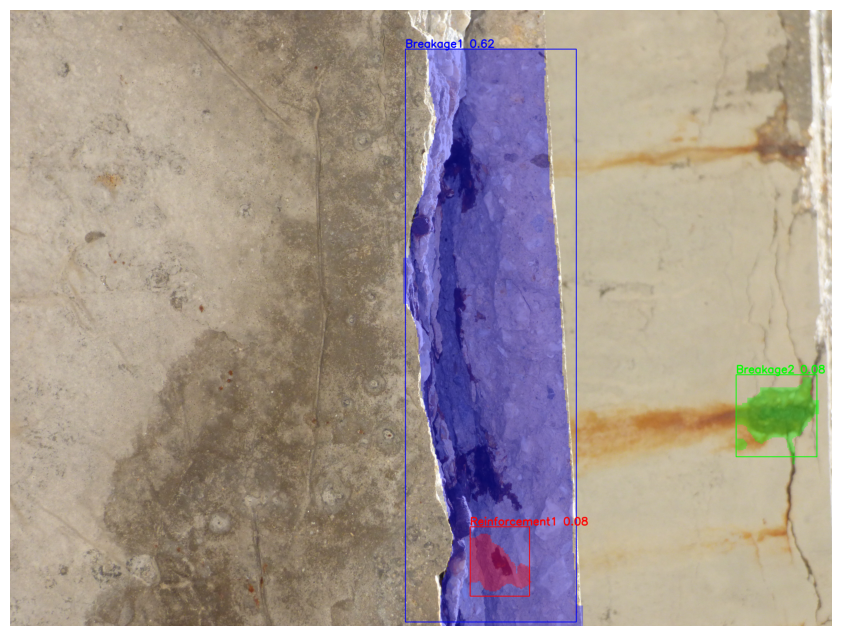

In [99]:
vis = result.orig_img.copy()

colors = [
    (255, 0, 0),
    (0, 255, 0),
    (0, 0, 255),
    (255, 255, 0),
    (255, 0, 255),
    (0, 255, 255),
]

for i, item in enumerate(merged_instances):
    color = colors[i % len(colors)]
    mask = item["mask"].astype(bool)
    x1, y1, x2, y2 = item["bbox"].astype(int)

    # mask 半透明叠加
    overlay = vis.copy()
    overlay[mask] = color
    vis = cv2.addWeighted(overlay, 0.35, vis, 0.65, 0)

    # bbox
    cv2.rectangle(vis, (x1, y1), (x2, y2), color, 3)

    # 标注名称 + 置信度
    label = f"{item['name']} {item['conf']:.2f}"
    cv2.putText(
        vis,
        label,
        (x1, max(0, y1 - 10)),
        cv2.FONT_HERSHEY_SIMPLEX,
        2.0,
        color,
        5,
        cv2.LINE_AA,
    )

plt.figure(figsize=(12, 8))
plt.imshow(vis[..., ::-1])
plt.axis("off")
plt.show()

In [111]:
import os

实例 1: Breakage1, conf=0.624, bbox=(2216, 219, 3174, 3433), 来源索引=[0]
截取图像尺寸: (3214, 958, 3)


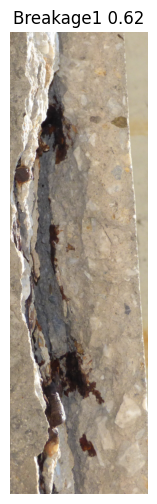

实例 1: Breakage1, conf=0.624, bbox=(2216, 219, 3174, 3433), 来源索引=[0]
截取图像尺寸: (3214, 958, 3)


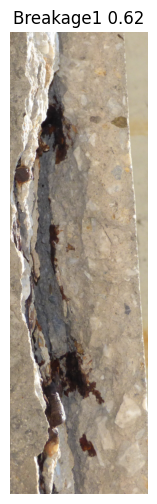

实例 2: Breakage2, conf=0.076, bbox=(4070, 2046, 4523, 2506), 来源索引=[2, 3, 4]
截取图像尺寸: (460, 453, 3)


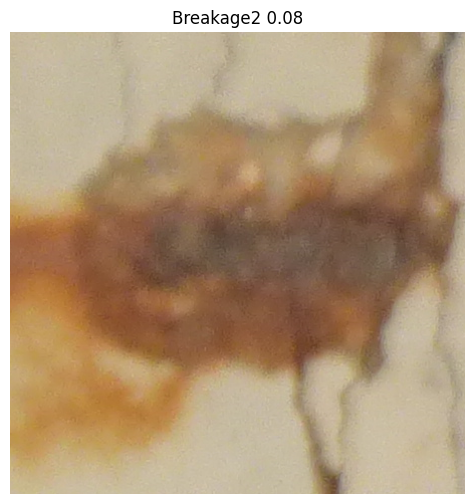

实例 1: Breakage1, conf=0.624, bbox=(2216, 219, 3174, 3433), 来源索引=[0]
截取图像尺寸: (3214, 958, 3)


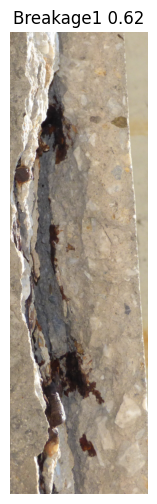

实例 2: Breakage2, conf=0.076, bbox=(4070, 2046, 4523, 2506), 来源索引=[2, 3, 4]
截取图像尺寸: (460, 453, 3)


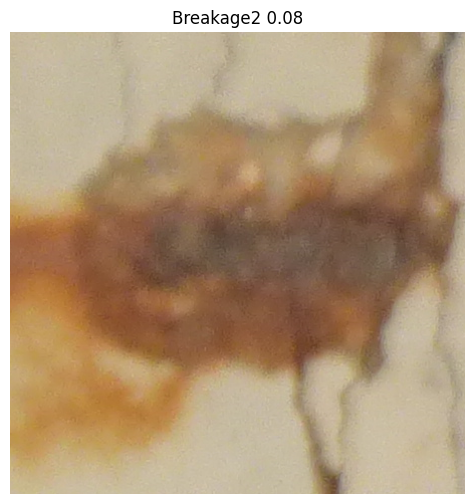

实例 3: Reinforcement1, conf=0.082, bbox=(2579, 2899, 2912, 3288), 来源索引=[1]
截取图像尺寸: (389, 333, 3)


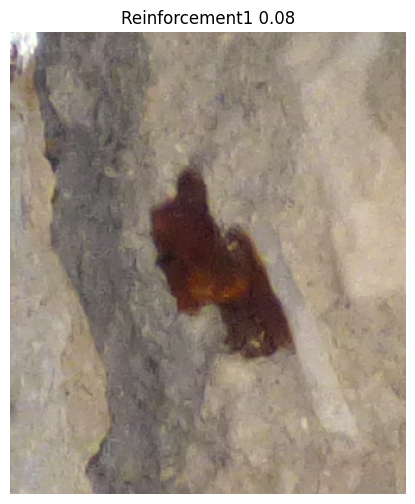

In [ ]:
os.makedirs("results", exist_ok=True)

for i, merged in enumerate(merged_instances, start=1):
    img = prediction_results[0].orig_img
    x1, y1, x2, y2 = merged["bbox"].astype(int)
    bbox_img = img[y1:y2, x1:x2]

    print(
        f"实例 {i}: {merged['name']}, conf={merged['conf']:.3f}, bbox=({x1}, {y1}, {x2}, {y2}), 来源索引={merged['indices']}"
    )
    print(f"截取图像尺寸: {bbox_img.shape}")

    plt.figure(figsize=(6, 6))
    plt.imshow(bbox_img[:, :, ::-1])  # 转换 BGR 到 RGB
    plt.title(f"{merged['name']} {merged['conf']:.2f}")
    plt.axis("off")
    plt.show()

    cv2.imwrite(f"results/bbox_img_{i}.png", bbox_img)

In [ ]:
for instance in merged_instances:
    mask = instance["mask"]

    # 1. mask 面积
    mask_area = int(mask.sum())

    # 2. 面积比（mask面积 / bbox面积）
    bbox_w, bbox_h = x2 - x1, y2 - y1
    bbox_area = bbox_w * bbox_h
    rectangularity = mask_area / bbox_area if bbox_area > 0 else 0

    # 3. 细长度（最小外接矩形的长宽比）
    mask_uint8 = (mask * 255).astype(np.uint8)
    contours, _ = cv2.findContours(mask_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        largest_contour = max(contours, key=cv2.contourArea)
        rect = cv2.minAreaRect(largest_contour)
        rw, rh = rect[1]
        slenderness = max(rw, rh) / min(rw, rh) if min(rw, rh) > 0 else 0
    else:
        slenderness = 0
        rect = None

    # 4. 主方向（最小外接矩形的角度）
    if rect is not None:
        major_direction = rect[2]
        if rect[1][0] < rect[1][1]:
            major_direction = 90 + major_direction
    else:
        major_direction = 0

    # 5. 边界复杂度（周长² / 面积）
    if contours:
        perimeter = cv2.arcLength(largest_contour, True)
        boundary_complexity = (perimeter ** 2) / mask_area if mask_area > 0 else 0
    else:
        boundary_complexity = 0

    # 6. 骨架长度 & 7. 分支数量
    skel = skeletonize(mask > 0).astype(np.uint8)
    skeleton_length = int(skel.sum())

    branch_points = 0
    end_points = 0
    h, w = skel.shape
    for i in range(1, h - 1):
        for j in range(1, w - 1):
            if skel[i, j] == 1:
                neighbors = skel[i-1:i+2, j-1:j+2].sum() - 1
                if neighbors >= 3:
                    branch_points += 1
                elif neighbors == 1:
                    end_points += 1

    # 8. 区域颜色统计
    # mask 尺寸可能与原图不一致，需缩放到原图大小
    if mask.shape != img.shape[:2]:
        mask_full = cv2.resize(mask, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_NEAREST)
    else:
        mask_full = mask
    mask_bool = mask_full.astype(bool)
    pixel_values = img[mask_bool]  # (N, 3) BGR
    color_mean = pixel_values.mean(axis=0)
    color_std = pixel_values.std(axis=0)

    # ========== 输出结果 ==========
    features = {
        "mask面积": mask_area,
        "面积比": round(rectangularity, 4),
        "细长度": round(slenderness, 4),
        "主方向(°)": round(major_direction, 2),
        "边界复杂度": round(boundary_complexity, 4),
        "骨架长度": skeleton_length,
        "分支数量": branch_points,
        "BGR均值": [round(v, 2) for v in color_mean],
        "BGR标准差": [round(v, 2) for v in color_std],
    }

    df = pd.DataFrame([features])
    print(df)

    mask面积      面积比     细长度  主方向(°)    边界复杂度  骨架长度  分支数量  \
0  2416608  18.6557  3.7032   86.07  31.3405  4374    24   

                      BGR均值                 BGR标准差  
0  [125.12, 140.51, 154.07]  [40.86, 46.12, 47.44]  
   mask面积     面积比     细长度  主方向(°)    边界复杂度  骨架长度  分支数量  \
0  115925  0.8949  1.1182  -64.17  33.7627   989    30   

                     BGR均值                 BGR标准差  
0  [84.32, 118.53, 154.37]  [27.96, 30.84, 27.12]  
   mask面积     面积比     细长度  主方向(°)    边界复杂度  骨架长度  分支数量  \
0   70614  0.5451  1.0681     0.0  31.6639   720    27   

                      BGR均值                BGR标准差  
0  [109.68, 121.19, 134.81]  [34.96, 39.5, 36.39]  


: 